In [1]:
%autosave 60

Autosaving every 60 seconds


# Метрики и бенчмарки RAG

В этом ноутбуке: зачем нужны бенчмарки для оценки RAG, метрики retrieval и generation, создание своих бенчмарков по двум источникам (Ростехнадзор и Новости) и оценка RAG из ноутбука [1.0] на этих бенчмарках.

## Настройка окружения

Загружаем переменные из `.env`, подключаем модели из `config`, инициализируем LLM через **Open Router** и эмбеддинги **HuggingFace** (Ollama не используется).

In [2]:
import os
import sys
import json
import numpy as np
import pandas as pd
from pathlib import Path

# Корень проекта
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "config.py").exists() else Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

env_path = PROJECT_ROOT / ".env"
if env_path.exists():
    from dotenv import load_dotenv
    load_dotenv(env_path)

from langchain_openai import ChatOpenAI
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import TextLoader, PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

from config import model_llm, model_embedding

PATH_PDF = PROJECT_ROOT / "data" / "text" / "data_v2.pdf"
PATH_TXT = PROJECT_ROOT / "data" / "audio" / "новое_производство_газотурбинного_оборудования.txt"

# LLM через Open Router (не Ollama)
llm = ChatOpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.environ.get("OPENROUTER_API_KEY"),
    model=model_llm,
    default_headers={"X-Title": "RAG Metrics Notebook"},
)

embeddings = HuggingFaceEmbeddings(model_name=model_embedding)

print("Окружение готово. LLM:", model_llm, "| Эмбеддинги:", model_embedding)

/Users/maxim/Desktop/STUDY/ai_agents_course/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 391/391 [00:00<00:00, 1861.99it/s, Materializing param=pooler.dense.weight]                               


Окружение готово. LLM: google/gemini-3.1-flash-lite-preview | Эмбеддинги: baai/bge-m3


## 1. Мотивация: зачем бенчмарки для RAG

RAG-пайплайн состоит из **retrieval** (поиск релевантных фрагментов) и **generation** (ответ по контексту). Чтобы улучшать систему, нужна объективная оценка:

- **Воспроизводимость**: одни и те же вопросы и эталоны позволяют сравнивать разные настройки (chunk_size, k, модели).
- **Разделение ответственности**: без размеченных пар «вопрос — релевантный чанк / эталонный ответ» нельзя понять, где ошибка — в поиске или в генерации.
- **Retrieval** оценивают по тому, попадает ли нужный документ в top-k.
- **Generation** оценивают по сходству ответа модели с эталонным ответом (ground truth).

Бенчмарк = набор пар (вопрос, эталонный ответ, индекс релевантного чанка). По нему считают метрики retrieval и generation.

## 2. Метрики retrieval и generation

### Retrieval

- **Recall@k** — доля запросов, для которых релевантный документ есть среди топ-k найденных. Для каждого k (1, 3, 5, 10) получаем 0 или 1 по запросу, затем среднее по выборке.
- **MRR (Mean Reciprocal Rank)** — среднее по выборке величины 1/rank, где rank — позиция первого релевантного документа в списке (если не найден — 0).

Для расчёта нужны размеченные пары: вопрос + индекс релевантного чанка (или сам текст чанка для сопоставления).

### Generation

Сравниваем ответ модели с эталонным (ground truth):

- **ROUGE** (ROUGE-1, ROUGE-L) — перекрытие n-грамм с эталоном (recall/fmeasure).
- **BLEU** — точность n-грамм относительно эталона.


![RAG схема](img/ROUGE.png)

- **BERTScore** — семантическое сходство через эмбеддинги (часто F1 по токенам).

![RAG схема](img/bert_score.png)

#### BERTScore — 
это метрика для оценки качества сгенерированного текста (перевод, суммаризация, ответы моделей и т.п.), которая вместо подсчёта пересечения n-грамм, как BLEU/ROUGE, измеряет **семантическое** сходство кандидата с эталонным текстом с помощью контекстных эмбеддингов трансформеров (BERT, RoBERTa и др.). Алгоритм расчёта: 
- 1 токенизируем кандидат и референс
- 2 прогоняем их через предобученную модель и получаем вектор для каждого токена
- 3 считаем косинусное сходство между каждым токеном кандидата и каждым токеном референса
- 4 для каждого токена берём максимум по строке/столбцу и агрегируем эти максимумы в усреднённые показатели precision (насколько токены кандидата “прикрыты” референсом), recall (насколько токены референса “прикрыты” кандидатом) и F1 в диапазоне. 

За счёт работы в embedding-пространстве метрика чувствительна к синонимам и переформулировкам и обычно лучше коррелирует с человеческими оценками, но при этом дороже вычислительно и может наследовать байасы и ограничения используемой модели. [arxiv](https://arxiv.org/pdf/1904.09675.pdf)

Ниже — короткий пример расчёта этих метрик на одной паре (reference vs candidate).

In [3]:
from rouge_score import rouge_scorer
import sacrebleu
from bert_score import score as bert_score_fun

reference = "Отгрузку руды в забое необходимо производить погрузочно-доставочными машинами с дистанционным управлением."
candidate = "Для отгрузки руды в забое нужно использовать погрузочно-доставочные машины с дистанционным управлением."

rouge = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=False)
r_scores = rouge.score(reference, candidate)
bleu = sacrebleu.sentence_bleu(candidate, [reference], smooth_method="exp").score / 100.0
_, _, bert_f1 = bert_score_fun(cands=[candidate], refs=[reference], lang="ru", verbose=False)

print("Reference:", reference[:60], "...")
print("Candidate:", candidate[:60], "...")
print("ROUGE-1 F:", round(r_scores["rouge1"].fmeasure, 4))
print("ROUGE-L F:", round(r_scores["rougeL"].fmeasure, 4))
print("BLEU:", round(bleu, 4))
print("BERTScore F1:", round(float(bert_f1[0]), 4))

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1444.09it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Reference: Отгрузку руды в забое необходимо производить погрузочно-дост ...
Candidate: Для отгрузки руды в забое нужно использовать погрузочно-дост ...
ROUGE-1 F: 0.0
ROUGE-L F: 0
BLEU: 0.2797
BERTScore F1: 0.9341


## 3. Создание своего бенчмарка для источника 1 (Ростехнадзор)

Загружаем документ Ростехнадзор, разбиваем на чанки (как в [1.0]), проставляем `chunk_idx` в metadata. Генерируем пары (вопрос, эталонный ответ, chunk_idx) с помощью LLM по выбранным чанкам — через Open Router.

In [4]:
# Загрузка и чанкинг Ростехнадзор, проставление chunk_idx
loader_pdf = PyPDFLoader(str(PATH_PDF))
docs_pdf_raw = loader_pdf.load()
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
splits_pdf = text_splitter.split_documents(docs_pdf_raw)
for i, doc in enumerate(splits_pdf):
    doc.metadata["chunk_idx"] = i

print("Чанков Ростехнадзор:", len(splits_pdf))

Чанков Ростехнадзор: 1300


In [5]:
def parse_qa(llm_output):
    """Из вывода LLM извлекаем вопрос и эталонный ответ (маркеры ВОПРОС:/ОТВЕТ:)."""
    raw = (llm_output or "").strip()
    question, answer = "", ""
    upper = raw.upper()
    for marker in ("ВОПРОС:", "ВОПРОС "):
        if marker in upper:
            idx = upper.find(marker)
            end = upper.find("ОТВЕТ:", idx + 1)
            if end == -1:
                end = len(raw)
            question = raw[idx + len(marker) : end].strip()
            if end < len(raw):
                answer = raw[end + 6 :].strip()
            break
    if not question and "\n" in raw:
        parts = raw.split("\n", 1)
        if parts[0].strip().endswith("?"):
            question = parts[0].strip()
            answer = parts[1].strip() if len(parts) > 1 else ""
    if not question:
        question = raw[:300].strip() or "О чём этот фрагмент?"
    if not answer:
        answer = raw[-500:].strip() if len(raw) > 500 else raw
    return question, answer

N_SAMPLES_PDF = 25
rng = np.random.default_rng(42)
indices_pdf = rng.choice(len(splits_pdf), size=min(N_SAMPLES_PDF, len(splits_pdf)), replace=False)

prompt_qa = """По фрагменту текста ниже придумай ОДИН конкретный вопрос (на который этот текст отвечает) и краткий эталонный ответ (1-3 предложения).
Формат ответа — только две строки:
ВОПРОС: твой вопрос
ОТВЕТ: краткий ответ

Текст:
{text}"""

samples_pdf = []
for i, idx in enumerate(indices_pdf):
    doc = splits_pdf[int(idx)]
    text = doc.page_content[:2500] if len(doc.page_content) > 2500 else doc.page_content
    prompt = prompt_qa.format(text=text)
    try:
        out = llm.invoke(prompt)
        raw = out.content if hasattr(out, "content") else str(out)
    except Exception:
        raw = ""
    question, ground_truth = parse_qa(raw)
    if not ground_truth:
        ground_truth = doc.page_content[:500]
    samples_pdf.append({"question": question, "ground_truth": ground_truth, "chunk_idx": int(idx)})
    print(f"  Сэмпл {i+1}/{N_SAMPLES_PDF}: вопрос len={len(question)}, ответ len={len(ground_truth)}")

  Сэмпл 1/25: вопрос len=130, ответ len=175
  Сэмпл 2/25: вопрос len=75, ответ len=174
  Сэмпл 3/25: вопрос len=106, ответ len=310
  Сэмпл 4/25: вопрос len=95, ответ len=127
  Сэмпл 5/25: вопрос len=124, ответ len=215
  Сэмпл 6/25: вопрос len=135, ответ len=169
  Сэмпл 7/25: вопрос len=73, ответ len=203
  Сэмпл 8/25: вопрос len=74, ответ len=239
  Сэмпл 9/25: вопрос len=99, ответ len=266
  Сэмпл 10/25: вопрос len=98, ответ len=149
  Сэмпл 11/25: вопрос len=120, ответ len=152
  Сэмпл 12/25: вопрос len=75, ответ len=167
  Сэмпл 13/25: вопрос len=121, ответ len=112
  Сэмпл 14/25: вопрос len=108, ответ len=231
  Сэмпл 15/25: вопрос len=69, ответ len=285
  Сэмпл 16/25: вопрос len=96, ответ len=108
  Сэмпл 17/25: вопрос len=79, ответ len=124
  Сэмпл 18/25: вопрос len=91, ответ len=139
  Сэмпл 19/25: вопрос len=94, ответ len=205
  Сэмпл 20/25: вопрос len=87, ответ len=294
  Сэмпл 21/25: вопрос len=92, ответ len=184
  Сэмпл 22/25: вопрос len=67, ответ len=219
  Сэмпл 23/25: вопрос len=108, отв

In [6]:
# Примеры из бенчмарка Ростехнадзор
artifacts_dir = Path(PROJECT_ROOT) / "notebooks_rag" / "artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)
with open(artifacts_dir / "samples_pdf.json", "w", encoding="utf-8") as f:
    json.dump(samples_pdf, f, ensure_ascii=False, indent=2)

for i, s in enumerate(samples_pdf[:2]):
    print(f"--- Пример {i+1} ---")
    print("Вопрос:", s["question"][:120], "..." if len(s["question"]) > 120 else "")
    print("Эталон:", s["ground_truth"][:150], "..." if len(s["ground_truth"]) > 150 else "")
    print("chunk_idx:", s["chunk_idx"])
    print()
print("Сохранено в", artifacts_dir / "samples_pdf.json")

--- Пример 1 ---
Вопрос: Каковы требования к высоте подвески контактного провода над головкой рельса на путях технологического железнодорожного т ...
Эталон: Высота подвески должна составлять не менее 6250 мм на станционных путях и не менее 5750 мм на перегонах. Данные параметры должны строго соответствоват ...
chunk_idx: 894

--- Пример 2 ---
Вопрос: Каковы требования к высоте и оборудованию ограждения строительной площадки? 
Эталон: Ограждение строительной площадки должно иметь высоту не менее 2 метров. В местах массового прохода людей его необходимо дополнительно оборудовать спло ...
chunk_idx: 480

Сохранено в /Users/maxim/Desktop/STUDY/ai_agents_course/notebooks_rag/artifacts/samples_pdf.json


## 4. Оценка RAG из [1.0] на бенчмарке источника 1 (Ростехнадзор)

Собираем тот же RAG: Chroma по `splits_pdf`, ретривер с k=10 (для расчёта recall@1,3,5,10), цепочка prompt → LLM. Считаем retrieval-метрики (recall@k, MRR) и generation-метрики (ROUGE, BLEU, BERTScore), выводим таблицу, график и разбор одного примера.

In [7]:
# RAG для Ростехнадзор: как в [1.0]
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

system_prompt = (
    "Ты — полезный ИИ-ассистент. Используй следующий контекст для ответа на вопрос пользователя. "
    "Если ответа в контексте нет, так и скажи.\n\nКонтекст: {context}"
)
prompt_rag = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("human", "{question}"),
])

vectorstore_pdf = Chroma.from_documents(
    documents=splits_pdf,
    embedding=embeddings,
    collection_name="rag_metrics_pdf",
)
retriever_pdf = vectorstore_pdf.as_retriever(search_kwargs={"k": 10})
rag_chain_pdf = (
    {"context": retriever_pdf | format_docs, "question": RunnablePassthrough()}
    | prompt_rag
    | llm
    | StrOutputParser()
)
print("RAG для Ростехнадзор собран (retriever k=10).")

RAG для Ростехнадзор собран (retriever k=10).


In [8]:
# Retrieval-метрики по бенчмарку Ростехнадзор
K_LIST = [1, 3, 5, 10]
retrieval_rows = []
for i, s in enumerate(samples_pdf):
    retrieved = retriever_pdf.invoke(s["question"])
    retrieved_indices = [d.metadata.get("chunk_idx", -1) for d in retrieved]
    rel_idx = s["chunk_idx"]
    rank = 0
    for pos, idx in enumerate(retrieved_indices, 1):
        if idx == rel_idx:
            rank = pos
            break
    recall_at_k = {f"recall@{k}": (1.0 if rel_idx in retrieved_indices[:k] else 0.0) for k in K_LIST}
    mrr = 1.0 / rank if rank else 0.0
    retrieval_rows.append({"sample_id": i, **recall_at_k, "mrr": mrr})

df_ret_pdf = pd.DataFrame(retrieval_rows)
means_ret_pdf = df_ret_pdf.drop(columns=["sample_id"]).mean()
print("Retrieval (Ростехнадзор), средние:")
print(means_ret_pdf.to_string())
df_ret_pdf

Retrieval (Ростехнадзор), средние:
recall@1     0.640000
recall@3     0.880000
recall@5     0.960000
recall@10    0.960000
mrr          0.771333


,sample_id,recall@1,recall@3,recall@5,recall@10,mrr
0,0,0.0,0.0,1.0,1.0,0.200000
1,1,1.0,1.0,1.0,1.0,1.000000
2,2,1.0,1.0,1.0,1.0,1.000000
3,3,0.0,1.0,1.0,1.0,0.500000
4,4,0.0,1.0,1.0,1.0,0.333333
5,5,1.0,1.0,1.0,1.0,1.000000
6,6,1.0,1.0,1.0,1.0,1.000000
7,7,0.0,1.0,1.0,1.0,0.500000
8,8,1.0,1.0,1.0,1.0,1.000000
9,9,1.0,1.0,1.0,1.0,1.000000


In [9]:
# Generation-метрики: ответ RAG vs эталон
rouge = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=False)
answers_pdf = [rag_chain_pdf.invoke(s["question"]) for s in samples_pdf]
refs_pdf = [s["ground_truth"][:500] for s in samples_pdf]
gen_rows = []
for i, (answer, ref) in enumerate(zip(answers_pdf, refs_pdf)):
    r1 = rouge.score(ref, answer)["rouge1"].fmeasure
    rL = rouge.score(ref, answer)["rougeL"].fmeasure
    bleu = sacrebleu.sentence_bleu(answer, [ref], smooth_method="exp").score / 100.0
    gen_rows.append({"sample_id": i, "rouge1_f": r1, "rougeL_f": rL, "bleu": bleu})
df_gen_pdf = pd.DataFrame(gen_rows)
_, _, F1 = bert_score_fun(cands=answers_pdf, refs=refs_pdf, lang="ru", verbose=False)
df_gen_pdf["bertscore_f1"] = F1.numpy()
means_gen_pdf = df_gen_pdf.drop(columns=["sample_id"]).mean()
print("Generation (Ростехнадзор), средние:")
print(means_gen_pdf.to_string())
df_gen_pdf

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1537.89it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generation (Ростехнадзор), средние:
rouge1_f        0.228671
rougeL_f        0.215338
bleu            0.093126
bertscore_f1    0.743480


,sample_id,rouge1_f,rougeL_f,bleu,bertscore_f1
0,0,0.307692,0.307692,0.010034,0.671825
1,1,0.500000,0.500000,0.048195,0.715200
2,2,0.000000,0.000000,0.020686,0.752206
3,3,0.000000,0.000000,0.030840,0.664367
4,4,0.000000,0.000000,0.029423,0.815469
5,5,0.000000,0.000000,0.059544,0.709274
6,6,0.000000,0.000000,0.161040,0.794891
7,7,0.000000,0.000000,0.048789,0.722193
8,8,0.000000,0.000000,0.019279,0.725941
9,9,0.000000,0.000000,0.088804,0.723391


,значение
recall@1,0.640000
recall@3,0.880000
recall@5,0.960000
recall@10,0.960000
mrr,0.771333
rouge1_f,0.228671
rougeL_f,0.215338
bleu,0.093126
bertscore_f1,0.743480


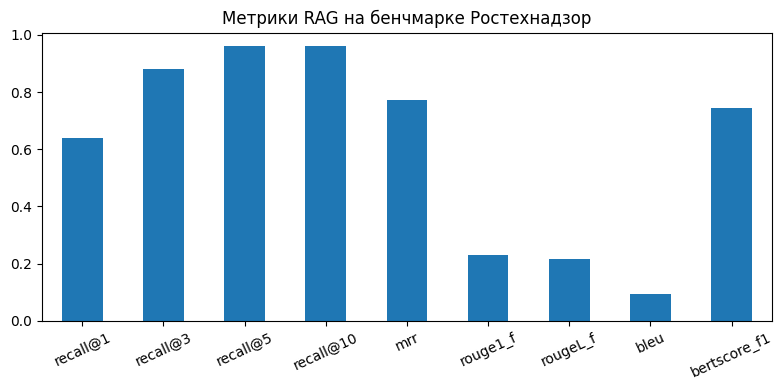

In [10]:
# Сводка метрик Ростехнадзор и график
import matplotlib.pyplot as plt
all_means_pdf = pd.concat([means_ret_pdf, means_gen_pdf])
display(all_means_pdf.to_frame("значение"))
all_means_pdf.plot(kind="bar", figsize=(8, 4), title="Метрики RAG на бенчмарке Ростехнадзор")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [11]:
# Разбор одного примера (Ростехнадзор)
ex = samples_pdf[0]
ans = answers_pdf[0]
ref = refs_pdf[0]
print("Вопрос:", ex["question"])
print("\nЭталон:", ref[:300], "..." if len(ref) > 300 else "")
print("\nОтвет RAG:", ans[:300], "..." if len(ans) > 300 else "")
print("\nМетрики по этому примеру: rouge1_f={:.4f}, rougeL_f={:.4f}, bleu={:.4f}, bertscore_f1={:.4f}".format(
    df_gen_pdf.iloc[0]["rouge1_f"], df_gen_pdf.iloc[0]["rougeL_f"], df_gen_pdf.iloc[0]["bleu"], df_gen_pdf.iloc[0]["bertscore_f1"]))

Вопрос: Каковы требования к высоте подвески контактного провода над головкой рельса на путях технологического железнодорожного транспорта?

Эталон: Высота подвески должна составлять не менее 6250 мм на станционных путях и не менее 5750 мм на перегонах. Данные параметры должны строго соответствовать проектной документации. 

Ответ RAG: Согласно предоставленному контексту, требования к высоте подвески контактного провода над уровнем головки рельса на технологическом железнодорожном транспорте следующие:

**Для постоянных путей:**
*   На станциях — не менее **6250 мм**.
*   На перегонах — не менее **5750 мм**.
*   В соответствии с т ...

Метрики по этому примеру: rouge1_f=0.3077, rougeL_f=0.3077, bleu=0.0100, bertscore_f1=0.6718


## 5. Создание своего бенчмарка для источника 2 (Новости)

Аналогично Ростехнадзор: загружаем Новости, чанкуем с тем же сплиттером, проставляем `chunk_idx`, генерируем N пар (вопрос, эталон, chunk_idx) через LLM по выбранным чанкам.

In [12]:
# Загрузка и чанкинг Новости, проставление chunk_idx
loader_txt = TextLoader(str(PATH_TXT), encoding="utf-8")
docs_txt_raw = loader_txt.load()
splits_txt = text_splitter.split_documents(docs_txt_raw)
for i, doc in enumerate(splits_txt):
    doc.metadata["chunk_idx"] = i
print("Чанков Новости:", len(splits_txt))

Чанков Новости: 8


In [13]:
# Генерация пар вопрос–ответ для Новости (Open Router)
N_SAMPLES_TXT = 5
rng_txt = np.random.default_rng(43)
indices_txt = rng_txt.choice(len(splits_txt), size=min(N_SAMPLES_TXT, len(splits_txt)), replace=False)
prompt_qa_txt = """По фрагменту текста ниже придумай ОДИН конкретный вопрос (на который этот текст отвечает) и краткий эталонный ответ (1-3 предложения).
Формат ответа — только две строки:
ВОПРОС: твой вопрос
ОТВЕТ: краткий ответ

Текст:
{text}"""

samples_txt = []
for i, idx in enumerate(indices_txt):
    doc = splits_txt[int(idx)]
    text = doc.page_content[:2500] if len(doc.page_content) > 2500 else doc.page_content
    try:
        raw = llm.invoke(prompt_qa_txt.format(text=text)).content
    except Exception:
        raw = ""
    question, ground_truth = parse_qa(raw)
    if not ground_truth:
        ground_truth = doc.page_content[:500]
    samples_txt.append({"question": question, "ground_truth": ground_truth, "chunk_idx": int(idx)})
    print(f"  Сэмпл {i+1}/{N_SAMPLES_TXT}: вопрос len={len(question)}, ответ len={len(ground_truth)}")

  Сэмпл 1/5: вопрос len=65, ответ len=288
  Сэмпл 2/5: вопрос len=105, ответ len=100
  Сэмпл 3/5: вопрос len=118, ответ len=200
  Сэмпл 4/5: вопрос len=89, ответ len=100
  Сэмпл 5/5: вопрос len=117, ответ len=116


In [14]:
# Примеры из бенчмарка Новости
with open(artifacts_dir / "samples_txt.json", "w", encoding="utf-8") as f:
    json.dump(samples_txt, f, ensure_ascii=False, indent=2)
for i, s in enumerate(samples_txt[:2]):
    print(f"--- Пример {i+1} ---")
    print("Вопрос:", s["question"][:120], "..." if len(s["question"]) > 120 else "")
    print("Эталон:", s["ground_truth"][:150], "..." if len(s["ground_truth"]) > 150 else "")
    print("chunk_idx:", s["chunk_idx"])
    print()
print("Сохранено в", artifacts_dir / "samples_txt.json")

--- Пример 1 ---
Вопрос: Чем занимается новое предприятие АМКОР, открытое в Зеленодольске? 
Эталон: Предприятие специализируется на полном цикле работ по восстановлению и производству критических компонентов горячего тракта для турбин General Electri ...
chunk_idx: 0

--- Пример 2 ---
Вопрос: Каким образом использование префаб-конструкций при строительстве жилья влияет на сроки возведения зданий? 
Эталон: Использование префаб-конструкций позволяет сократить сроки строительства зданий в среднем на 30–50%. 
chunk_idx: 4

Сохранено в /Users/maxim/Desktop/STUDY/ai_agents_course/notebooks_rag/artifacts/samples_txt.json


## 6. Оценка RAG из [1.0] на бенчмарке источника 2 (Новости)

Тот же пайплайн: Chroma по `splits_txt`, retriever k=10, та же цепочка prompt → LLM. Считаем recall@k, MRR, ROUGE, BLEU, BERTScore; таблица, график и краткое сравнение с Ростехнадзор.

In [15]:
# RAG для Новости (как в [1.0])
vectorstore_txt = Chroma.from_documents(
    documents=splits_txt,
    embedding=embeddings,
    collection_name="rag_metrics_txt",
)
retriever_txt = vectorstore_txt.as_retriever(search_kwargs={"k": 10})
rag_chain_txt = (
    {"context": retriever_txt | format_docs, "question": RunnablePassthrough()}
    | prompt_rag
    | llm
    | StrOutputParser()
)
print("RAG для Новости собран (retriever k=10).")

RAG для Новости собран (retriever k=10).


In [16]:
# Retrieval-метрики по бенчмарку Новости
retrieval_rows_txt = []
for i, s in enumerate(samples_txt):
    retrieved = retriever_txt.invoke(s["question"])
    retrieved_indices = [d.metadata.get("chunk_idx", -1) for d in retrieved]
    rel_idx = s["chunk_idx"]
    rank = 0
    for pos, idx in enumerate(retrieved_indices, 1):
        if idx == rel_idx:
            rank = pos
            break
    recall_at_k = {f"recall@{k}": (1.0 if rel_idx in retrieved_indices[:k] else 0.0) for k in K_LIST}
    mrr = 1.0 / rank if rank else 0.0
    retrieval_rows_txt.append({"sample_id": i, **recall_at_k, "mrr": mrr})
df_ret_txt = pd.DataFrame(retrieval_rows_txt)
means_ret_txt = df_ret_txt.drop(columns=["sample_id"]).mean()
print("Retrieval (Новости), средние:")
print(means_ret_txt.to_string())
df_ret_txt

Retrieval (Новости), средние:
recall@1     1.0
recall@3     1.0
recall@5     1.0
recall@10    1.0
mrr          1.0


,sample_id,recall@1,recall@3,recall@5,recall@10,mrr
0,0,1.0,1.0,1.0,1.0,1.0
1,1,1.0,1.0,1.0,1.0,1.0
2,2,1.0,1.0,1.0,1.0,1.0
3,3,1.0,1.0,1.0,1.0,1.0
4,4,1.0,1.0,1.0,1.0,1.0


In [17]:
# Generation-метрики по бенчмарку Новости
answers_txt = [rag_chain_txt.invoke(s["question"]) for s in samples_txt]
refs_txt = [s["ground_truth"][:500] for s in samples_txt]
gen_rows_txt = []
for i, (answer, ref) in enumerate(zip(answers_txt, refs_txt)):
    r1 = rouge.score(ref, answer)["rouge1"].fmeasure
    rL = rouge.score(ref, answer)["rougeL"].fmeasure
    bleu = sacrebleu.sentence_bleu(answer, [ref], smooth_method="exp").score / 100.0
    gen_rows_txt.append({"sample_id": i, "rouge1_f": r1, "rougeL_f": rL, "bleu": bleu})
df_gen_txt = pd.DataFrame(gen_rows_txt)
_, _, F1_txt = bert_score_fun(cands=answers_txt, refs=refs_txt, lang="ru", verbose=False)
df_gen_txt["bertscore_f1"] = F1_txt.numpy()
means_gen_txt = df_gen_txt.drop(columns=["sample_id"]).mean()
print("Generation (Новости), средние:")
print(means_gen_txt.to_string())
df_gen_txt

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1694.94it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generation (Новости), средние:
rouge1_f        0.800000
rougeL_f        0.800000
bleu            0.243878
bertscore_f1    0.844213


,sample_id,rouge1_f,rougeL_f,bleu,bertscore_f1
0,0,1.0,1.0,0.237084,0.825132
1,1,1.0,1.0,0.300943,0.898138
2,2,1.0,1.0,0.202158,0.757218
3,3,0.0,0.0,0.091035,0.869328
4,4,1.0,1.0,0.388172,0.871246


,значение
recall@1,1.000000
recall@3,1.000000
recall@5,1.000000
recall@10,1.000000
mrr,1.000000
rouge1_f,0.800000
rougeL_f,0.800000
bleu,0.243878
bertscore_f1,0.844213


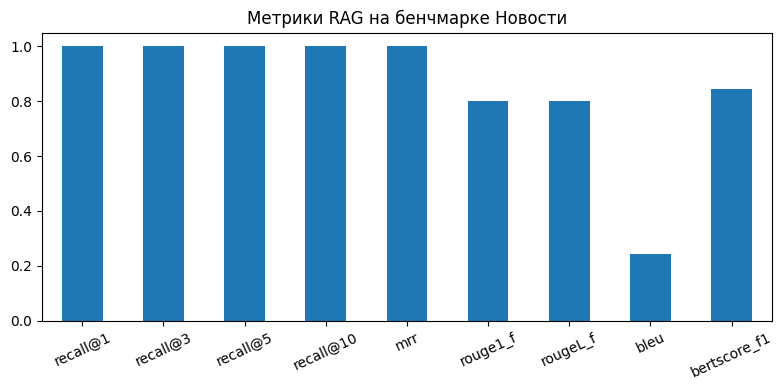

In [18]:
# Сводка метрик Новости и график
import matplotlib.pyplot as plt
all_means_txt = pd.concat([means_ret_txt, means_gen_txt])
display(all_means_txt.to_frame("значение"))
all_means_txt.plot(kind="bar", figsize=(8, 4), title="Метрики RAG на бенчмарке Новости")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

### Сравнение Ростехнадзор и Новости

- **Ростехнадзор**: много чанков, нормативный текст — retrieval может быть сложнее (похожие формулировки), generation зависит от того, насколько ретривер подтянул нужный фрагмент.
- **Новости**: меньше чанков, текст проще — часто выше recall и MRR; метрики generation могут быть выше при удачном попадании контекста.

Сводная таблица ниже позволяет сравнить средние метрики по двум источникам.

In [19]:
# Сводная таблица: Ростехнадзор vs Новости
comparison = pd.DataFrame({"Ростехнадзор": all_means_pdf, "Новости": all_means_txt})
comparison

,Ростехнадзор,Новости
recall@1,0.640000,1.000000
recall@3,0.880000,1.000000
recall@5,0.960000,1.000000
recall@10,0.960000,1.000000
mrr,0.771333,1.000000
rouge1_f,0.228671,0.800000
rougeL_f,0.215338,0.800000
bleu,0.093126,0.243878
bertscore_f1,0.743480,0.844213
